# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

We use these because real-world relationships are often not purely linear. Linear models can predict any value (including impossible ones like probabilities <0 or >1), while models like logistic regression apply an activation function (sigmoid) to map outputs into meaningful ranges (like 0–1 for probabilities). This makes them more appropriate for tasks like classification and better at capturing nonlinear patterns.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross-entropy directly measures how close predicted probabilities are to the true labels. Logistic regression outputs probabilities, so cross-entropy penalizes confident wrong predictions heavily and rewards accurate probability estimates. This aligns perfectly with the goal of classification.

3. True or false, and explain: Logistic regression is a linear model.

True (with nuance).It is linear in the parameters (weights applied to inputs), but the output is passed through a nonlinear sigmoid function, making the final prediction nonlinear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is specifically designed for classification, especially binary classification, by predicting probabilities and applying a threshold (like 0.5).

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. In logistic regression, coefficients represent the change in the log-odds, not the direct probability. A 1-unit increase in a feature changes the log of the odds, not the probability itself.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Feature engineering is still very important. Logistic regression is only linear in features, so if relationships are complex, you need transformations (e.g., interactions, polynomials) to capture them.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better for classification, but linear regression is better for predicting continuous values. The “best” model depends on the problem.


In [1]:
! git clone https://github.com/richarddo3/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 30 (delta 8), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (30/30), 30.43 KiB | 2.03 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Download complete
Extracting data files...
Data extracted


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
!git clone https://github.com/richarddo3/undergrad_ml_assignments.git

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 191 (delta 2), reused 1 (delta 1), pack-reused 186 (from 2)
Receiving objects: 100% (191/191), 13.95 MiB | 28.23 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [5]:
import pandas as pd

df = pd.read_csv("undergrad_ml_assignments/data/data.csv", sep=";")

In [8]:
#2.1
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]

In [9]:
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [10]:
df.shape

(4424, 6)

In [11]:
df["dropout"] = (df["Target"] == "Dropout").astype(int)

In [12]:
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


I filtered the dataset to the relevant variables and handled missing values by removing rows with missing data to ensure consistency in modeling.

In [13]:
#2.2
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [15]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


The logistic regression results show that being a debtor and having a higher age at enrollment are associated with an increased probability of dropout, as both variables have positive coefficients. In contrast, being up to date on tuition and holding a scholarship are associated with a decreased probability of dropout, as indicated by their negative coefficients. Notably, the coefficient for “Tuition fees up to date” is strongly negative, suggesting that being up to date on tuition significantly reduces dropout risk. Overall, staying current on tuition appears to be one of the most important factors in lowering the likelihood of dropout.

In [18]:
#2.3
df["pred_prob"] = model.predict_proba(X)[:, 1]

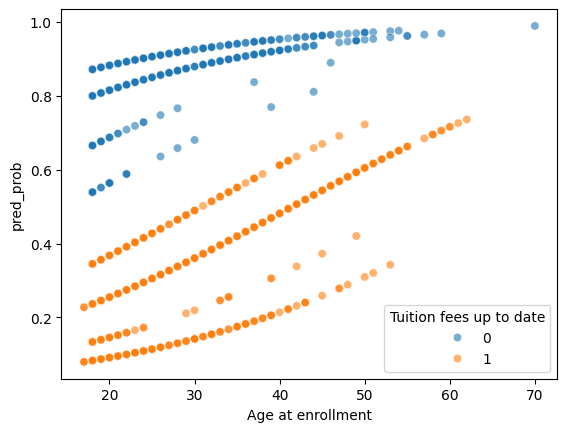

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date",
    alpha=0.6
)
plt.show()

The scatter plot shows that students who are not up to date on tuition consistently have higher predicted dropout probabilities compared to those who are up to date. This pattern holds across all ages, indicating that being up to date on tuition significantly reduces dropout risk. Additionally, dropout probability tends to increase with age for both groups. The reduction in dropout probability from being up to date on tuition appears relatively consistent across ages, rather than being concentrated at a specific age range.

In [20]:
df.groupby("Tuition fees up to date")["pred_prob"].mean()

,pred_prob
Tuition fees up to date,
0,0.860675
1,0.248090


In [21]:
diff = (
    df[df["Tuition fees up to date"] == 0]["pred_prob"].mean()
    - df[df["Tuition fees up to date"] == 1]["pred_prob"].mean()
)

print(diff)

0.6125849339840048


The average predicted probability of dropout for students who are not up to date on tuition is approximately 0.86, while for students who are up to date it is approximately 0.25. This indicates a substantial difference of about 0.61, meaning that being up to date on tuition reduces the predicted probability of dropout by over 60 percentage points on average. This reinforces the earlier finding that tuition status is one of the strongest predictors of dropout risk.

In [22]:
#2.4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print(acc)

[[2841  162]
 [ 891  530]]
0.7619801084990958


The confusion matrix shows that the model correctly predicts a large number of non-dropout students (2841 true negatives) and a smaller number of dropout students (530 true positives). However, the model also misses a significant number of actual dropouts (891 false negatives), indicating that it struggles to identify all students at risk. The overall accuracy of the model is approximately 76.2%, suggesting that it performs reasonably well overall, but may not be as effective at detecting dropout cases specifically.

In [23]:
#2.5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_prob"] = lin_model.predict(X)

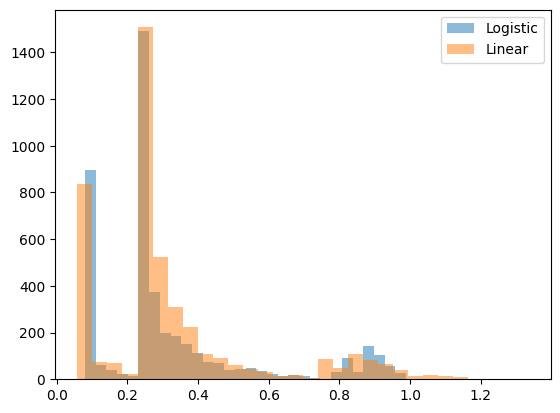

In [24]:
import matplotlib.pyplot as plt

plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.show()

The histogram shows that the logistic regression model produces predicted probabilities that are bounded between 0 and 1, which is appropriate for modeling probabilities. In contrast, the linear model produces some predicted values greater than 1, which are not valid probabilities. While both models show similar overall distributions, the logistic regression model is more appropriate for this task because it ensures predictions remain within a meaningful range. Therefore, logistic regression provides more reliable and interpretable probability estimates for dropout risk.

#2.6
Students who are most at risk of dropping out are those who have outstanding debt, are not up to date on tuition, do not hold scholarships, and are older at enrollment, particularly given that tuition status had the largest effect on predicted dropout probability. These factors were associated with higher predicted dropout probabilities in the logistic regression model.

Possible interventions include providing financial support such as tuition assistance or payment plans, expanding scholarship opportunities, and offering targeted advising or support programs for older students. Early identification of at-risk students could allow institutions to intervene before dropout occurs.

In [25]:
#2.7

from sklearn.linear_model import LogisticRegression

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

multi_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
multi_model.fit(X_multi, y_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [26]:
from sklearn.metrics import confusion_matrix

y_pred_multi = multi_model.predict(X_multi)

cm_multi = confusion_matrix(y_multi, y_pred_multi)
print(cm_multi)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


In [27]:
print(set(y_pred_multi))

{'Dropout', 'Graduate'}


In [28]:
probs = multi_model.predict_proba(X_multi)
print(probs[:5])

[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


In [29]:
print(multi_model.classes_)

['Dropout' 'Enrolled' 'Graduate']


The multinomial logistic regression model predicts the three classes Dropout, Enrolled, and Graduate. However, the confusion matrix shows that the model does not predict the “Enrolled” class at all, as the corresponding column contains only zeros. Instead, the model only predicts “Dropout” and “Graduate.” This suggests that the model struggles to distinguish the Enrolled class, possibly due to class imbalance or overlapping feature patterns.

The hard classification therefore does not predict every class, since “Enrolled” is never predicted. In contrast, the predicted probabilities from the model include values for all three classes for each observation, as shown by the output of predict_proba. This indicates that while the model assigns probabilities to all classes, it ultimately selects only the most likely class during hard classification, which results in some classes being omitted.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [30]:
import pandas as pd

df3 = pd.read_csv("undergrad_ml_assignments/data/cirrhosis.csv")

In [31]:
#3.1

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df3 = df3[cols]

In [32]:
df3.isna().sum()

,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


In [33]:
df3 = df3.dropna()

In [34]:
#3.2

df3["survival"] = df3["Status"].isin(["C", "CL"]).astype(int)

In [35]:
df3 = pd.get_dummies(df3, columns=["Edema", "Drug"], drop_first=True)

I filtered the dataset to the relevant variables and handled missing values by removing rows with missing data to ensure consistency in modeling.

In [36]:
from sklearn.linear_model import LogisticRegression

X = df3.drop(columns=["Status", "survival"])
y = df3["survival"]

model3 = LogisticRegression(max_iter=1000)
model3.fit(X, y)

LogisticRegression(max_iter=1000)

In [37]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model3.coef_[0]
})

print(coef_df)

        Feature  Coefficient
0     Bilirubin    -0.308674
1         Stage    -0.558590
2       Edema_S    -0.334178
3       Edema_Y    -1.364685
4  Drug_Placebo     0.313009


The logistic regression results show that higher bilirubin levels are associated with lower survival probability, as indicated by the negative coefficient. Similarly, more advanced disease stage and the presence of edema (especially severe edema) are associated with reduced survival, with larger negative effects for more severe edema.

The coefficient for Drug_Placebo is positive, indicating that patients receiving the placebo have higher survival probability compared to those receiving the drug. This suggests that the drug does not improve survival and may be less effective than the placebo in this dataset.

In [38]:
#3.3

df3["pred_prob"] = model3.predict_proba(X)[:, 1]

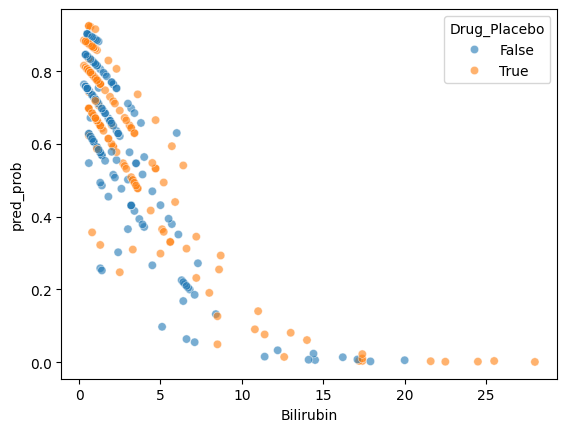

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df3,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_Placebo",
    alpha=0.6
)
plt.show()

The scatter plot shows that survival probability decreases as bilirubin levels increase, indicating that higher bilirubin is associated with worse outcomes. Comparing patients by treatment, those receiving the placebo generally have higher predicted survival probabilities than those receiving the drug across most bilirubin values. This suggests that the drug does not improve survival and may be less effective than the placebo. The difference between the groups is most noticeable at lower to moderate bilirubin levels, where survival probabilities are higher overall.

In [40]:
df3.groupby("Drug_Placebo")["pred_prob"].mean()

,pred_prob
Drug_Placebo,
False,0.590591
True,0.608341


In [41]:
diff = (
    df3[df3["Drug_Placebo"] == True]["pred_prob"].mean()
    - df3[df3["Drug_Placebo"] == False]["pred_prob"].mean()
)

print(diff)

0.017749751473634223


On average, patients receiving the placebo have a slightly higher predicted survival probability than those receiving the drug. The difference is approximately 0.018, indicating that the placebo group has about a 1.8 percentage point higher survival probability. This suggests that the drug does not meaningfully improve survival and may even perform slightly worse than the placebo in this dataset.

In [42]:
#3.4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred3 = model3.predict(X)

cm3 = confusion_matrix(y, y_pred3)
acc3 = accuracy_score(y, y_pred3)

print(cm3)
print(acc3)

[[ 66  59]
 [ 16 171]]
0.7596153846153846


The confusion matrix shows that the model correctly classifies many observations, particularly for patients who survive (171 true positives). However, there are also a number of misclassifications, including 59 false positives and 16 false negatives. The overall accuracy of the model is approximately 76.0%, indicating that it performs reasonably well in predicting survival outcomes. While the model is better at identifying survivors than non-survivors, it still makes some errors, particularly in predicting patients who do not survive.

In [44]:
#3.5

from sklearn.linear_model import LinearRegression

lin_model3 = LinearRegression()
lin_model3.fit(X, y)

df3["lin_prob"] = lin_model3.predict(X)

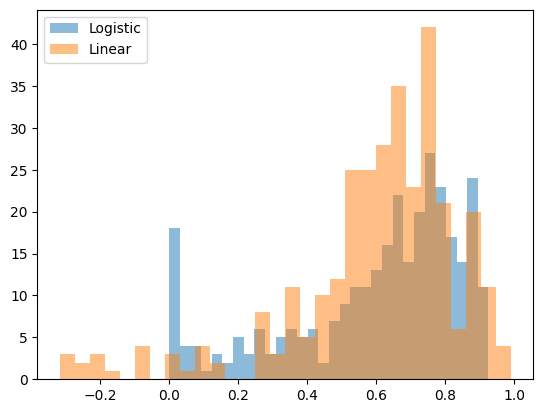

In [45]:
import matplotlib.pyplot as plt

plt.hist(df3["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df3["lin_prob"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.show()

In [46]:
#3.6

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_stage = df3.drop(columns=["Status", "survival"])
y_stage = df3["Stage"]

multi_stage = LogisticRegression(max_iter=1000)
multi_stage.fit(X_stage, y_stage)

y_pred_stage = multi_stage.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_pred_stage)
print(cm_stage)

print(set(y_pred_stage))

probs_stage = multi_stage.predict_proba(X_stage)
print(probs_stage[:5])
print(multi_stage.classes_)

[[ 15   1   0   0]
 [  0  67   0   0]
 [  0   0 120   0]
 [  0   0   0 109]]
{np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)}
[[1.07628323e-09 2.20221222e-05 2.81549620e-02 9.71823015e-01]
 [5.97344843e-04 7.19052426e-02 8.75089486e-01 5.24079270e-02]
 [2.09663120e-08 5.66453497e-05 6.15616359e-02 9.38381698e-01]
 [1.88775911e-08 5.44071163e-05 6.00476942e-02 9.39897880e-01]
 [2.44642059e-04 6.74028443e-02 8.80006881e-01 5.23456329e-02]]
[1. 2. 3. 4.]


The logistic regression model for Stage performs very well, as shown by the confusion matrix, which is almost entirely diagonal. This indicates that the model correctly predicts nearly all observations, with only a minimal number of misclassifications. Importantly, the hard classification predicts all classes (Stages 1 through 4), as confirmed by the set of predicted values.

The predicted probabilities from the model also provide values for all classes for each observation, as shown by the output of predict_proba. Each observation is assigned a probability for every possible stage, giving a complete representation of classification uncertainty. Overall, both the hard classification and probability predictions successfully capture all classes in this model.

The histogram shows that the logistic regression model produces predicted probabilities that are bounded between 0 and 1, which is appropriate for modeling survival probabilities. In contrast, the linear model produces some predicted values outside this range, including negative values, which are not valid probabilities. While both models capture similar general trends, the logistic regression model is more appropriate because it ensures predictions remain within a meaningful and interpretable range. Therefore, logistic regression provides more reliable probability estimates for survival outcomes.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

#4.1

A one-unit increase in feature $x_k$ increases the prediction by exactly $b_k$.  
The effect is constant and does not depend on the value of $x$.

#4.2

The derivative with respect to feature $x_k$ is:

$$
\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1 - \hat{p})
$$

A one-unit increase in $x_k$ changes the predicted probability by  
$b_k \cdot \hat{p}(1 - \hat{p})$.

This effect depends on the value of $\hat{p}$:
- Largest when $\hat{p} \approx 0.5$
- Smaller when $\hat{p}$ is close to 0 or 1

Thus, unlike the linear model, the effect is not constant.

When $\hat{p} \approx 0.5$, we have $\hat{p}(1 - \hat{p}) \approx 0.25$, so the effect is approximately $b_k / 4$. Therefore, multiplying the coefficient by 4 gives a rough estimate of how a one-unit change in $x_k$ affects the predicted probability when $\hat{p}$ is near 0.5.

#4.3

We can rewrite the model as:

$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x
$$

The derivative with respect to $x_k$ is:

$$
\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b_k
$$

**Interpretation:**  
A one-unit increase in $x_k$ increases the **log-odds** of the outcome by $b_k$.